# Data Analysis

## Step 1: Import the Required Libraries

In [1]:
import pandas as pd

## Step 2: Load the Data

In [2]:
customers = pd.read_parquet("../../data/cleaned/customers.parquet")
transactions = pd.read_parquet("../../data/cleaned/transactions.parquet")

## Step 2: Data Analysis

### 5.1 GroupBy

#### 1. Number of Transactions by Product Category
**Question:**  
How many transactions are there in each `product_category`?

In [7]:
transactions.groupby("product_category").size()

product_category
Audio Equipment             1884
Bedding                      639
Computer Accessories         628
Cookware                     639
Desktop Computers            664
Furniture                   3905
Gaming Consoles             1892
Home Decor                  3704
Kitchen Appliances          3693
Laptops                     1889
Small Kitchen Appliances    1331
Smart Home Devices          4314
Smartphones                 4407
TVs                         1346
Tablets                      674
dtype: int64

###### 2. Total Quantity Sold by Product Category

**Question:**  
What is the total `quantity` sold for each `product_category`?

In [8]:
transactions.groupby("product_category")["quantity"].sum()

product_category
Audio Equipment             2557.0
Bedding                      922.0
Computer Accessories         887.0
Cookware                     945.0
Desktop Computers            879.0
Furniture                   5575.0
Gaming Consoles             2769.0
Home Decor                  5349.0
Kitchen Appliances          5255.0
Laptops                     2573.0
Small Kitchen Appliances    1763.0
Smart Home Devices          6153.0
Smartphones                 6153.0
TVs                         1890.0
Tablets                      865.0
Name: quantity, dtype: float64

In [9]:
transactions.groupby("product_category")["price"].mean()

product_category
Audio Equipment              282.297617
Bedding                      166.558404
Computer Accessories          85.617008
Cookware                     234.017642
Desktop Computers           1310.933109
Furniture                   1131.319625
Gaming Consoles              399.800865
Home Decor                   163.963989
Kitchen Appliances           568.576497
Laptops                     1543.525912
Small Kitchen Appliances     114.898002
Smart Home Devices           170.998102
Smartphones                  818.649018
TVs                         1722.793568
Tablets                      508.919076
Name: price, dtype: float64

In [10]:
transactions.groupby("payment_method").size()

payment_method
Apple Pay       3160
Cash            1573
Credit Card    10907
Debit Card      7968
Gift Card       1596
Google Pay      1633
PayPal          4798
dtype: int64

In [11]:
transactions.groupby("store_location").size()

store_location
Atlanta, GA           1563
Boston, MA            1528
Chicago, IL           1559
Denver, CO            1529
Houston, TX           1630
Los Angeles, CA       1470
Miami, FL             1587
New York, NY          1562
Online               16108
San Francisco, CA     1579
Seattle, WA           1536
dtype: int64

In [12]:
transactions.groupby("product_name")["quantity"].sum()

product_name
Air Fryer          351.0
Amazon Echo       1217.0
Amazon Fire HD     172.0
Area Rug          1139.0
Asus ROG           175.0
                   ...  
Xbox Series X      545.0
Xiaomi Mi 12      1301.0
iMac               149.0
iPad Pro           158.0
iPhone 13         1257.0
Name: quantity, Length: 75, dtype: float64

In [13]:
transactions.groupby("store_location")["price"].mean()

store_location
Atlanta, GA          621.450025
Boston, MA           600.225786
Chicago, IL          638.619438
Denver, CO           636.789431
Houston, TX          652.167290
Los Angeles, CA      629.671041
Miami, FL            592.223265
New York, NY         640.478284
Online               621.117036
San Francisco, CA    619.150720
Seattle, WA          604.621162
Name: price, dtype: float64

In [14]:
transactions.groupby("product_category")["discount_applied"].sum()

product_category
Audio Equipment              9755.0
Bedding                      3080.0
Computer Accessories         3400.0
Cookware                     3070.0
Desktop Computers            3665.0
Furniture                   20390.0
Gaming Consoles              9675.0
Home Decor                  19430.0
Kitchen Appliances          19670.0
Laptops                     10035.0
Small Kitchen Appliances     6750.0
Smart Home Devices          21065.0
Smartphones                 22090.0
TVs                          7005.0
Tablets                      3760.0
Name: discount_applied, dtype: float64

In [15]:
transactions.groupby("store_location")["customer_id"].nunique()

store_location
Atlanta, GA          1073
Boston, MA           1045
Chicago, IL          1050
Denver, CO           1056
Houston, TX          1106
Los Angeles, CA      1017
Miami, FL            1085
New York, NY         1056
Online               2962
San Francisco, CA    1088
Seattle, WA          1041
Name: customer_id, dtype: int64

In [7]:
transactions["sales"]= transactions["price"] * transactions["quantity"]

In [17]:
transactions.groupby("product_category")["sales"].sum()

product_category
Audio Equipment             7.054164e+05
Bedding                     1.469980e+05
Computer Accessories        7.711132e+04
Cookware                    2.186455e+05
Desktop Computers           1.131150e+06
Furniture                   6.164426e+06
Gaming Consoles             1.112971e+06
Home Decor                  8.765199e+05
Kitchen Appliances          2.945759e+06
Laptops                     3.963159e+06
Small Kitchen Appliances    1.955924e+05
Smart Home Devices          1.019499e+06
Smartphones                 4.972433e+06
TVs                         3.260835e+06
Tablets                     4.161080e+05
Name: sales, dtype: float64

In [18]:
transactions.columns

Index(['transaction_id', 'customer_id', 'product_name', 'product_category',
       'quantity', 'price', 'transaction_date', 'store_location',
       'payment_method', 'discount_applied', 'sales'],
      dtype='str')

In [32]:
transactions.groupby("product_category").agg(
    total_sales=("sales", "sum"),
    avg_price=("price", "mean"),
    total_quantity=("quantity", "sum"),
    transaction_count=("transaction_id", "size")
)

,total_sales,avg_price,total_quantity,transaction_count
product_category,,,,
Audio Equipment,7.054164e+05,282.297617,2557.0,1884
Bedding,1.469980e+05,166.558404,922.0,639
Computer Accessories,7.711132e+04,85.617008,887.0,628
Cookware,2.186455e+05,234.017642,945.0,639
Desktop Computers,1.131150e+06,1310.933109,879.0,664
Furniture,6.164426e+06,1131.319625,5575.0,3905
Gaming Consoles,1.112971e+06,399.800865,2769.0,1892
Home Decor,8.765199e+05,163.963989,5349.0,3704
Kitchen Appliances,2.945759e+06,568.576497,5255.0,3693


In [33]:
transactions.columns

Index(['transaction_id', 'customer_id', 'product_name', 'product_category',
       'quantity', 'price', 'transaction_date', 'store_location',
       'payment_method', 'discount_applied', 'sales'],
      dtype='str')

In [35]:
transactions.groupby("store_location")["price"].agg(
    ["max","min","mean"]
)

,max,min,mean
store_location,,,
"Atlanta, GA",10497.603601,19.80,621.450025
"Boston, MA",4789.389941,18.74,600.225786
"Chicago, IL",6860.409559,17.61,638.619438
"Denver, CO",15883.655075,19.28,636.789431
"Houston, TX",14640.685851,22.32,652.167290
"Los Angeles, CA",6156.011105,18.00,629.671041
"Miami, FL",7582.074856,19.87,592.223265
"New York, NY",7512.117904,17.45,640.478284
Online,21371.648592,17.52,621.117036


### 5.2 Merge

In [63]:
merged = pd.merge(customers,transactions , on="customer_id")

In [12]:
merged.head()

,customer_id,full_name,age,gender,email,phone,street_address,city,state,zip_code,...,preferred_channel,transaction_id,product_name,product_category,quantity,price,transaction_date,store_location,payment_method,discount_applied
0,4c30e132-0704-4459-a509-9eddde934977,Mark Johnson,40.0,Male,mark.johnson@yahoo.com,989.608.3863,819 Johnson Course,Houston,Texas,29158.0,...,NaN,ec438dca-2c1a-4769-ab19-e5310a92712a,Xiaomi Mi 12,Smartphones,1.0,955.37,2024-07-31,"Miami, FL",Credit Card,0.0
1,4c30e132-0704-4459-a509-9eddde934977,Mark Johnson,40.0,Male,mark.johnson@yahoo.com,989.608.3863,819 Johnson Course,Houston,Texas,29158.0,...,NaN,cd5c1596-bc06-479c-9556-e9abcdc1784c,Office Desk,Furniture,1.0,832.93,2024-08-23,"Denver, CO",Debit Card,NaN
2,4c30e132-0704-4459-a509-9eddde934977,Mark Johnson,40.0,Male,mark.johnson@yahoo.com,989.608.3863,819 Johnson Course,Houston,Texas,29158.0,...,NaN,2acd8488-0e95-405c-9639-de32d2b9291a,Dining Table,Furniture,1.0,1777.42,2024-12-17,"Chicago, IL",PayPal,0.0
3,68bec407-275f-4b5b-9a82-13d02f54626a,Robert Smith,33.0,Male,smithr@yahoo.com,(518)349-5931x0341,35116 Michael Key Suite 078,Austin,Texas,16862.0,...,in-store,035ce41a-e6b9-4b1c-abd8-a839f2539d4a,Electric Range,Kitchen Appliances,1.0,145.06,2023-12-02,"Denver, CO",Debit Card,0.0
4,68bec407-275f-4b5b-9a82-13d02f54626a,Robert Smith,33.0,Male,smithr@yahoo.com,(518)349-5931x0341,35116 Michael Key Suite 078,Austin,Texas,16862.0,...,in-store,21ad14b0-9310-4d8a-83cd-a53b04686a18,NaN,Kitchen Appliances,2.0,811.30,2022-11-11,"Los Angeles, CA",Apple Pay,0.0


In [21]:
merged.groupby("city")["sales"].sum()

city
Akron             312065.010000
Albany            554969.204485
Alexandria        217428.005296
Allentown         393651.819978
Ann Arbor         245962.915776
                      ...      
Tucson            116960.800000
Vancouver         159214.291264
Virginia Beach    262861.212669
Winston-Salem     190831.352157
Worcester         193818.447428
Name: sales, Length: 74, dtype: float64

In [22]:
merged.groupby("gender").size()

gender
Female               15514
Male                 14885
Non-binary             839
Prefer not to say      327
dtype: int64

In [23]:
merged.groupby("preferred_channel")["sales"].sum()

preferred_channel
both        9.616093e+06
in-store    4.195728e+06
online      1.344225e+07
Name: sales, dtype: float64

In [24]:
merged.groupby("age")["sales"].mean()

age
18.0     923.022241
19.0     884.579255
20.0     900.102160
21.0    1079.961925
22.0    1009.882614
23.0     838.723936
24.0     926.111378
25.0     855.881081
26.0     794.381104
27.0    1195.667515
28.0     877.527353
29.0     885.095318
30.0     878.830985
31.0     807.078493
32.0     857.319020
33.0     776.123117
34.0     764.949040
35.0     858.882193
36.0     804.772615
37.0     874.868884
38.0     864.814113
39.0     807.714058
40.0     872.313726
41.0     806.655937
42.0     815.645209
43.0     860.938712
44.0     797.226111
45.0    1247.837653
46.0    1214.294008
47.0     957.616168
48.0     976.005690
49.0    1063.974037
50.0     845.516942
51.0    1054.013985
52.0    1105.281336
53.0     941.171764
54.0    1212.961050
55.0     903.603063
56.0    1212.103803
57.0     886.196102
58.0     914.713544
59.0    1255.179245
60.0    1047.218458
61.0     870.885843
62.0     822.239583
63.0     984.652158
64.0     746.466667
65.0    1650.896452
66.0    1340.747368
67.0     588.388

In [25]:
merged.groupby("state")["quantity"].sum()

state
Arizona           1433.0
California        8048.0
Florida           5114.0
Georgia           2088.0
Illinois          2725.0
Massachusetts     1304.0
Michigan          2077.0
New Jersey        1531.0
New York          4322.0
North Carolina    2021.0
Ohio              2453.0
Pennsylvania      2810.0
Texas             5710.0
Virginia          1651.0
Washington        1403.0
Name: quantity, dtype: float64

In [38]:
merged.groupby("city").agg(
    transactions_number=("transaction_id" , "size"),
    total_sales=("sales","sum"),
    avg_sales=("sales" ,"mean")
    
)

,transactions_number,total_sales,avg_sales
city,,,
Akron,318,312065.010000,1013.198084
Albany,665,554969.204485,860.417371
Alexandria,245,217428.005296,909.740608
Allentown,466,393651.819978,884.610831
Ann Arbor,309,245962.915776,814.446741
...,...,...,...
Tucson,180,116960.800000,680.004651
Vancouver,216,159214.291264,772.884909
Virginia Beach,337,262861.212669,813.811804


### 5.3 Pivot Table

In [26]:
merged.pivot_table(index="product_category" , columns="store_location" , values="quantity" , aggfunc="sum")

store_location,"Atlanta, GA","Boston, MA","Chicago, IL","Denver, CO","Houston, TX","Los Angeles, CA","Miami, FL","New York, NY",Online,"San Francisco, CA","Seattle, WA"
product_category,,,,,,,,,,,
Audio Equipment,120.0,214.0,96.0,89.0,106.0,91.0,106.0,70.0,1437.0,95.0,76.0
Bedding,45.0,40.0,42.0,22.0,43.0,75.0,35.0,50.0,455.0,31.0,28.0
Computer Accessories,39.0,37.0,24.0,43.0,44.0,60.0,45.0,48.0,444.0,40.0,47.0
Cookware,37.0,47.0,36.0,33.0,45.0,45.0,40.0,38.0,520.0,53.0,37.0
Desktop Computers,52.0,30.0,41.0,52.0,37.0,43.0,39.0,39.0,435.0,49.0,42.0
Furniture,237.0,290.0,286.0,240.0,286.0,256.0,296.0,259.0,2713.0,300.0,288.0
Gaming Consoles,117.0,136.0,85.0,121.0,136.0,117.0,139.0,143.0,1517.0,88.0,110.0
Home Decor,225.0,288.0,272.0,277.0,227.0,285.0,263.0,263.0,2583.0,296.0,291.0
Kitchen Appliances,336.0,233.0,214.0,240.0,309.0,278.0,266.0,250.0,2507.0,302.0,230.0


In [27]:
merged.pivot_table(index="product_category" , columns="payment_method" , values="sales" , aggfunc="sum")

payment_method,Apple Pay,Cash,Credit Card,Debit Card,Gift Card,Google Pay,PayPal
product_category,,,,,,,
Audio Equipment,69433.572404,36799.486353,2.500749e+05,1.727209e+05,31655.890000,36032.160000,93127.290000
Bedding,15523.922720,4695.860000,4.417068e+04,3.698963e+04,8813.720000,7792.420000,26072.269857
Computer Accessories,9235.740000,2917.430000,2.330715e+04,2.246756e+04,3344.510000,3607.120000,10547.460000
Cookware,25569.500000,10300.270000,7.162351e+04,5.646131e+04,9325.130000,11295.400000,31961.369971
Desktop Computers,111229.750000,49503.600000,3.560326e+05,3.316878e+05,58666.390000,57050.310000,149915.600000
Furniture,641912.849239,424066.589259,2.029055e+06,1.403421e+06,299408.230000,259244.610000,980779.645453
Gaming Consoles,93923.025091,43762.330000,4.000157e+05,2.800580e+05,46109.550000,39870.427665,175487.147802
Home Decor,84532.023034,50467.925557,3.227467e+05,1.897395e+05,52638.455236,43465.388357,120847.201442
Kitchen Appliances,272417.004318,134656.820000,1.026413e+06,7.894908e+05,142772.212498,124197.360000,405458.131104


In [28]:
merged.pivot_table(index="product_category" , columns="store_location"  , aggfunc="size")

store_location,"Atlanta, GA","Boston, MA","Chicago, IL","Denver, CO","Houston, TX","Los Angeles, CA","Miami, FL","New York, NY",Online,"San Francisco, CA","Seattle, WA"
product_category,,,,,,,,,,,
Audio Equipment,94,99,82,72,67,76,85,57,1068,77,61
Bedding,35,30,32,18,35,31,28,34,336,25,22
Computer Accessories,31,32,22,34,34,27,37,39,292,30,34
Cookware,29,36,28,25,29,33,29,25,320,46,27
Desktop Computers,39,24,32,41,32,28,31,31,324,34,32
Furniture,188,204,213,192,233,171,205,199,1813,196,198
Gaming Consoles,66,72,67,79,90,68,82,82,1085,67,89
Home Decor,181,208,196,200,189,171,209,194,1692,203,192
Kitchen Appliances,207,177,170,185,200,186,192,193,1732,205,172


In [29]:
merged.pivot_table(index="product_category" , columns="city"  , values="sales", aggfunc="sum")

city,Akron,Albany,Alexandria,Allentown,Ann Arbor,Arlington,Athens,Atlanta,Augusta,Austin,...,Tallahassee,Tampa,Tempe,Toledo,Trenton,Tucson,Vancouver,Virginia Beach,Winston-Salem,Worcester
product_category,,,,,,,,,,,,,,,,,,,,,
Audio Equipment,3490.66,14538.780000,2663.980000,10677.660000,5107.110000,2155.670000,5321.930000,5393.160000,4876.51,17604.050000,...,14720.900000,13124.888356,1596.20,4096.570000,15997.891393,2596.14,4908.320000,3708.551532,3172.770000,3618.400000
Bedding,1903.58,3299.650000,320.930000,1778.640000,964.590000,1615.630000,1053.020000,1415.860000,1044.87,3051.190000,...,2485.560000,8966.400000,366.48,2167.910000,533.170000,1159.12,384.900000,790.860000,336.450000,830.330000
Computer Accessories,557.35,976.280000,128.780000,1338.530000,354.560000,462.110000,195.970000,701.430000,283.70,1428.930000,...,2016.714230,1089.330000,280.84,784.490000,1234.324940,622.55,271.540000,263.710000,156.040000,180.090000
Cookware,1747.74,2539.890000,756.420000,3165.440000,1799.420000,539.500000,1675.290000,2293.830000,1609.72,5285.020000,...,6983.480000,4382.430000,574.00,1771.000000,1339.540000,823.01,1048.720000,1803.060000,401.250000,4797.368579
Desktop Computers,8550.89,25816.130000,10189.320000,16674.800000,17930.510000,7763.430000,7439.340000,10333.070000,4261.10,70875.410000,...,27705.070000,23953.550000,3411.38,6917.510000,8060.030000,1068.84,7591.380000,12333.880000,4248.240000,9899.080000
Furniture,111123.72,137745.208533,35402.100000,99112.440000,69190.360000,65718.270000,50995.790000,32334.680000,45864.62,178156.500000,...,118811.737157,100440.120000,15189.21,68703.530000,36041.800000,28688.51,45453.060000,81755.541138,27870.180000,37150.690000
Gaming Consoles,23584.42,26032.340000,8827.760000,8902.780000,3511.000000,27855.560000,7223.587802,10755.440000,7561.63,22868.780000,...,41563.110000,14171.490000,5008.76,4637.320000,6713.420000,7121.92,13855.920000,9399.850000,7808.270000,7530.950000
Home Decor,7240.13,16262.360000,4935.900000,10081.834387,8515.120000,9230.829044,16697.930000,6648.260000,5406.43,23146.780000,...,28551.741055,17435.030000,2188.24,6207.740000,6275.705955,5411.90,2499.480000,10985.080000,9233.450000,6451.640000
Kitchen Appliances,22506.34,58597.420000,37463.899154,55869.045506,29358.200000,7739.730000,25414.920000,19199.190000,21337.00,79350.686374,...,59263.910000,56929.836862,28453.45,32852.901129,22623.440000,11964.33,20502.010000,27014.180000,12866.680000,26661.198849


In [30]:
merged.pivot_table(index="gender" , columns="preferred_channel" , values="customer_id"  , aggfunc="nunique")

preferred_channel,both,in-store,online
gender,,,
Female,681,386,1112
Male,594,439,1041
Non-binary,35,22,57
Prefer not to say,19,8,23


### 2.3 value_counts

In [39]:
customers["city"].value_counts()

city
Sacramento       188
San Jose         187
San Diego        184
Los Angeles      173
San Francisco    146
                ... 
Lowell            28
Cambridge         28
Spokane           28
Jersey City       27
Tempe             22
Name: count, Length: 74, dtype: int64

In [40]:
transactions["payment_method"].value_counts()

payment_method
Credit Card    10907
Debit Card      7968
PayPal          4798
Apple Pay       3160
Google Pay      1633
Gift Card       1596
Cash            1573
Name: count, dtype: int64

In [41]:
transactions["product_category"].value_counts()

product_category
Smartphones                 4407
Smart Home Devices          4314
Furniture                   3905
Home Decor                  3704
Kitchen Appliances          3693
Gaming Consoles             1892
Laptops                     1889
Audio Equipment             1884
TVs                         1346
Small Kitchen Appliances    1331
Tablets                      674
Desktop Computers            664
Cookware                     639
Bedding                      639
Computer Accessories         628
Name: count, dtype: int64

In [45]:
customers["preferred_channel"].value_counts()

preferred_channel
online      2473
both        1457
in-store     956
Name: count, dtype: int64

### 2.4 query

In [47]:
transactions.query("price>500")

,transaction_id,customer_id,product_name,product_category,quantity,price,transaction_date,store_location,payment_method,discount_applied,sales
2,ba85240a-2b5d-4987-ac0a-efb6a4a57d6d,d296bf0d-92bb-4670-a578-2fd3553cf7c8,Samsung Galaxy S22,Smartphones,2.0,1335.880000,2021-10-28,Online,PayPal,30.0,2671.760000
4,de1b05a5-68c7-4b00-a068-e8c2f13f0dab,8595dcfa-2bfc-46f4-a15a-042af85b78cd,MacBook Pro,Laptops,1.0,985.150000,2022-08-30,"Atlanta, GA",Credit Card,0.0,985.150000
6,2936863b-85c8-410d-8ff7-ae59fa28ce8b,1b194bc2-2033-4e79-912c-91e3fd9d02cc,Range Hood,Kitchen Appliances,NaN,989.550000,2022-12-24,"Denver, CO",Gift Card,0.0,NaN
9,0b0e3abe-fbe2-478b-b36f-6a5f95f27a9f,2bfcd9ca-a7e1-48ab-8a46-9b2804333a53,NaN,Kitchen Appliances,1.0,1033.261129,2024-01-08,Online,Debit Card,10.0,1033.261129
21,0d50a336-b157-42cf-8d42-b4324b0677dd,b77212a9-915d-489e-8a2c-632d38185f57,Xiaomi Mi 12,Smartphones,2.0,564.780000,2023-05-11,Online,NaN,25.0,1129.560000
...,...,...,...,...,...,...,...,...,...,...,...
32278,3b2280cb-48cd-4e99-b08f-6eacb122831c,3286075b-9bd7-44eb-afb0-dc792d2ccd67,MacBook Pro,Laptops,1.0,2195.200000,2023-10-07,Online,PayPal,0.0,2195.200000
32279,6666f9c9-69d8-4179-a55f-47aff1232669,8cdbb0f8-2626-43cf-811b-84720f40acff,OnePlus 10,Smartphones,2.0,829.000000,2021-04-07,"New York, NY",Google Pay,0.0,1658.000000
32280,ad202ba9-5937-4a0e-acf6-57940eaeebae,395d8d94-f72f-4434-98cf-2a9c0af430e4,Dell XPS 15,Laptops,1.0,1281.070000,2024-08-21,"Denver, CO",Gift Card,10.0,1281.070000
32283,f958e002-84ab-41ff-9346-da462758ba54,ae343f95-681a-4507-a5d6-89c88bf280b4,iPhone 13,Smartphones,2.0,691.420000,2024-11-28,Online,Cash,0.0,1382.840000


In [48]:
transactions.query("quantity>5")

,transaction_id,customer_id,product_name,product_category,quantity,price,transaction_date,store_location,payment_method,discount_applied,sales
658,0bec2109-99bd-47b5-bd3b-8719c46d53a0,a3f9a48e-b2f2-4228-b827-dea4411e7762,Bed Frame,Furniture,17.0,673.15,2024-10-17,Online,Credit Card,0.0,11443.55
821,b7260db1-d74a-41c7-b094-c54d41bbfda8,120d232b-79a5-4c29-a4f1-ea5dd79ddfa0,Dishwasher,Kitchen Appliances,15.0,560.79,2022-12-20,Online,Debit Card,10.0,8411.85
856,0cd0c245-ce84-481b-a743-869a3ec54686,f4532ac4-018f-46de-8234-bf463150ae47,Wall Art,Home Decor,12.0,276.00,2022-10-30,"Miami, FL",PayPal,0.0,3312.00
903,3069e02d-d7bc-4f51-8d79-20a06181fc33,60191fc4-d3f5-4e83-8b96-ba0e7dca376b,Google Nest,Smart Home Devices,10.0,35.60,2025-02-10,"Chicago, IL",Credit Card,0.0,356.00
954,20c41500-14d7-4e26-9258-3ac4da9bebf2,1314d51f-c6fc-4302-82b8-28f8fb36f1e8,Google Pixel 6,Smartphones,23.0,831.78,2025-02-20,Online,Credit Card,30.0,19130.94
...,...,...,...,...,...,...,...,...,...,...,...
31437,0596d16b-7909-4ce7-84d1-4bf11dbd2f30,a0f3977f-3877-4fc6-937d-7130d1f05138,Philips Hue Lights,Smart Home Devices,36.0,221.25,2020-08-29,Online,Debit Card,0.0,7965.00
31595,092e75d6-cf3c-4041-b901-4aa927e36ad9,17c2193e-1c9d-46bf-854d-982b3454718e,Area Rug,Home Decor,36.0,50.11,2024-06-08,Online,Cash,0.0,1803.96
31685,2c1a75d5-5f03-4a20-b537-c317a225b1e2,30ae1aeb-0897-4117-9cff-ff4168ec11b7,Ring Doorbell,Smart Home Devices,15.0,291.84,2022-08-22,Online,Debit Card,0.0,4377.60
32058,dcd438ea-dc43-439f-b3c3-437caa90eed2,1deb9a7c-b674-4b3c-8e37-1ff0b439e0a1,Office Desk,Furniture,21.0,511.15,2024-06-17,Online,Gift Card,0.0,10734.15


In [49]:
customers.query("age>40")

,customer_id,full_name,age,gender,email,phone,street_address,city,state,zip_code,registration_date,preferred_channel
2,4466459f-76c8-433c-814e-6d59cb4131fc,Jamie Chavez,42.0,Female,jchavez@gmail.com,364.583.5030x564,419 Amanda Gardens,Detroit,Michigan,21918.0,2023-12-14,online
3,04c36a25-02f3-462c-92b0-6bf291c57706,Thomas Bradley,53.0,Male,thomas.bradley@hotmail.com,(332)887-1012x269,7242 Julie Plain Suite 969,Fort Worth,Texas,52851.0,2022-07-11,both
6,d7c50fae-43b8-4945-86f8-b8f9d4d2d71a,Jennifer Powers,53.0,Female,jennifer.powers@yahoo.com,001-403-910-5183x473,31509 Brianna Avenue,Tempe,Arizona,9806.0,2021-04-10,in-store
7,d61d8f7b-c2d0-4548-9f3b-da16dc3146ad,David Kennedy,44.0,Male,david_kennedy@gmail.com,NaN,6670 Bruce Stream Suite 133,Tucson,Arizona,25432.0,2022-09-04,in-store
9,a960dd54-ee35-4731-b29e-d8de6c5793dc,Jonathan Farrell,41.0,Male,jfarrell@gmail.com,569-698-5435,91361 Beth Canyon,Syracuse,New York,81684.0,2022-01-24,in-store
...,...,...,...,...,...,...,...,...,...,...,...,...
4991,80de7f23-a7e6-4344-836c-2bf7779e32a4,Vanessa Cannon,43.0,Female,vanessa.cannon@gmail.com,NaN,848 Evans Extension,Allentown,Pennsylvania,3478.0,2023-09-14,both
4993,5f9fc3e5-697d-420b-8c2b-33042fa0c938,Sierra Huerta,41.0,Female,sierra.huerta@yahoo.com,+1-993-467-2858x695,36349 Taylor Ford,Austin,Texas,35815.0,2023-09-19,online
4996,2252e41a-d482-41a4-8962-15a86d48099f,Autumn Martin,43.0,Female,autumn_martin@gmail.com,001-447-839-5231x6761,74328 James Villages Apt. 727,Allentown,Pennsylvania,17520.0,2024-12-19,both
4997,fb4e194c-7591-4017-b298-d84cddbce122,Laurie Miller,72.0,Female,millerl@hotmail.com,001-549-978-4978x0862,37521 Joseph Dam Suite 919,Buffalo,New York,31641.0,2023-09-07,both


In [50]:
transactions.query("sales>1000")

,transaction_id,customer_id,product_name,product_category,quantity,price,transaction_date,store_location,payment_method,discount_applied,sales
2,ba85240a-2b5d-4987-ac0a-efb6a4a57d6d,d296bf0d-92bb-4670-a578-2fd3553cf7c8,Samsung Galaxy S22,Smartphones,2.0,1335.880000,2021-10-28,Online,PayPal,30.0,2671.760000
9,0b0e3abe-fbe2-478b-b36f-6a5f95f27a9f,2bfcd9ca-a7e1-48ab-8a46-9b2804333a53,NaN,Kitchen Appliances,1.0,1033.261129,2024-01-08,Online,Debit Card,10.0,1033.261129
21,0d50a336-b157-42cf-8d42-b4324b0677dd,b77212a9-915d-489e-8a2c-632d38185f57,Xiaomi Mi 12,Smartphones,2.0,564.780000,2023-05-11,Online,NaN,25.0,1129.560000
23,68f67ed8-4071-47cd-b264-e6cdf68e9421,cf1a3b7a-0250-4ed4-afb2-34293bbcd15e,MacBook Pro,Laptops,1.0,1640.560000,2022-12-19,Online,Debit Card,20.0,1640.560000
24,968ea7e4-e97d-489c-989d-397cdf1118cb,89037bc9-389d-484e-b6b4-9f627833f2df,Sony Bravia,TVs,1.0,2634.270000,2021-04-03,Online,Credit Card,0.0,2634.270000
...,...,...,...,...,...,...,...,...,...,...,...
32278,3b2280cb-48cd-4e99-b08f-6eacb122831c,3286075b-9bd7-44eb-afb0-dc792d2ccd67,MacBook Pro,Laptops,1.0,2195.200000,2023-10-07,Online,PayPal,0.0,2195.200000
32279,6666f9c9-69d8-4179-a55f-47aff1232669,8cdbb0f8-2626-43cf-811b-84720f40acff,OnePlus 10,Smartphones,2.0,829.000000,2021-04-07,"New York, NY",Google Pay,0.0,1658.000000
32280,ad202ba9-5937-4a0e-acf6-57940eaeebae,395d8d94-f72f-4434-98cf-2a9c0af430e4,Dell XPS 15,Laptops,1.0,1281.070000,2024-08-21,"Denver, CO",Gift Card,10.0,1281.070000
32283,f958e002-84ab-41ff-9346-da462758ba54,ae343f95-681a-4507-a5d6-89c88bf280b4,iPhone 13,Smartphones,2.0,691.420000,2024-11-28,Online,Cash,0.0,1382.840000


In [52]:
transactions.query("quantity>3 and price>100 ")

,transaction_id,customer_id,product_name,product_category,quantity,price,transaction_date,store_location,payment_method,discount_applied,sales
295,7fc2cc31-da44-42f2-bda6-673eb4a83a2f,ce6983a4-5c04-4536-b93e-2670508343d1,Microwave Oven,Kitchen Appliances,4.0,220.28,2023-11-02,Online,Debit Card,0.0,881.12
658,0bec2109-99bd-47b5-bd3b-8719c46d53a0,a3f9a48e-b2f2-4228-b827-dea4411e7762,Bed Frame,Furniture,17.0,673.15,2024-10-17,Online,Credit Card,0.0,11443.55
821,b7260db1-d74a-41c7-b094-c54d41bbfda8,120d232b-79a5-4c29-a4f1-ea5dd79ddfa0,Dishwasher,Kitchen Appliances,15.0,560.79,2022-12-20,Online,Debit Card,10.0,8411.85
856,0cd0c245-ce84-481b-a743-869a3ec54686,f4532ac4-018f-46de-8234-bf463150ae47,Wall Art,Home Decor,12.0,276.00,2022-10-30,"Miami, FL",PayPal,0.0,3312.00
954,20c41500-14d7-4e26-9258-3ac4da9bebf2,1314d51f-c6fc-4302-82b8-28f8fb36f1e8,Google Pixel 6,Smartphones,23.0,831.78,2025-02-20,Online,Credit Card,30.0,19130.94
...,...,...,...,...,...,...,...,...,...,...,...
31685,2c1a75d5-5f03-4a20-b537-c317a225b1e2,30ae1aeb-0897-4117-9cff-ff4168ec11b7,Ring Doorbell,Smart Home Devices,15.0,291.84,2022-08-22,Online,Debit Card,0.0,4377.60
31853,3815d870-1e18-4cbb-8a84-476d95831191,25597440-51a5-4c25-92f6-9306dfe2d042,Vizio SmartCast TV,TVs,4.0,1200.90,2020-11-05,"Houston, TX",Gift Card,0.0,4803.60
32058,dcd438ea-dc43-439f-b3c3-437caa90eed2,1deb9a7c-b674-4b3c-8e37-1ff0b439e0a1,Office Desk,Furniture,21.0,511.15,2024-06-17,Online,Gift Card,0.0,10734.15
32200,1f9cc366-2553-4fba-8942-1671c3641362,6e6908f1-2462-43d0-abb4-93999539964a,MacBook Pro,Laptops,4.0,512.45,2024-05-08,"Atlanta, GA",PayPal,0.0,2049.80


In [55]:
customers["age_group"] = customers["age"].apply(
    lambda age : "young" if age > 25 
    else "adult" if age <= 40
    else "Senior")

In [61]:
transactions["sales_level"] = transactions["sales"].apply(
    lambda level : "low" if level < 100 
    else "Medium" if   100 <= level <=500
    else "High"
)

### 2.4 melt

In [7]:
pd.melt(
    transactions ,
    id_vars=["transaction_id"],
    value_vars=["quantity" , "price" , "discount_applied"],
    var_name= "variable",
    value_name="value"
)

,transaction_id,variable,value
0,53e3d9f5-6231-46de-aa39-e5f8eaae2eee,quantity,1.0
1,ae6e6edf-f2fe-45c8-989c-c01e77eade0c,quantity,1.0
2,ba85240a-2b5d-4987-ac0a-efb6a4a57d6d,quantity,2.0
3,3725a285-2a2b-4a80-b317-7c8041cd9b8b,quantity,1.0
4,de1b05a5-68c7-4b00-a068-e8c2f13f0dab,quantity,1.0
...,...,...,...
96880,f02767eb-03e5-40f6-9097-80b8c8ab5fad,discount_applied,30.0
96881,47eaf0c3-0ec2-4b1d-8744-f293dfdc1c00,discount_applied,0.0
96882,3253670e-e9c0-426e-9b0d-6b290d2e9f6b,discount_applied,0.0
96883,5b00bd45-fd9e-44e2-bb56-084176b75fb7,discount_applied,0.0


In [17]:
merged.columns

Index(['customer_id', 'full_name', 'age', 'gender', 'email', 'phone',
       'street_address', 'city', 'state', 'zip_code', 'registration_date',
       'preferred_channel', 'transaction_id', 'product_name',
       'product_category', 'quantity', 'price', 'transaction_date',
       'store_location', 'payment_method', 'discount_applied'],
      dtype='str')

In [21]:
transactions[["product_name","quantity" , "price" , "sales"]]

,product_name,quantity,price,sales
0,Ring Doorbell,1.0,140.07,140.07
1,Oculus Quest,1.0,339.57,339.57
2,Samsung Galaxy S22,2.0,1335.88,2671.76
3,External Hard Drive,1.0,91.56,91.56
4,MacBook Pro,1.0,985.15,985.15
...,...,...,...,...
32290,Wall Art,1.0,221.83,221.83
32291,Sony Soundbar,1.0,NaN,NaN
32292,Bookshelf,2.0,268.85,537.70
32293,Table Lamp,1.0,230.69,230.69


In [30]:
melted= pd.melt(
   transactions,
   id_vars=["product_name"],
   value_vars=["quantity" , "price" , "sales"],
   var_name="variabls",
   value_name="value"
)

In [31]:
customers["gender"]

0         Male
1         Male
2       Female
3         Male
4       Female
         ...  
4995      Male
4996    Female
4997    Female
4998      Male
4999    Female
Name: gender, Length: 5000, dtype: str

In [32]:
customers["gender"].map({
    "Male" : "m" ,
    "Female" : "f"
})

0       m
1       m
2       f
3       m
4       f
       ..
4995    m
4996    f
4997    f
4998    m
4999    f
Name: gender, Length: 5000, dtype: str

In [35]:
transactions["price"].map(lambda x : x*2)

0         280.14
1         679.14
2        2671.76
3         183.12
4        1970.30
          ...   
32290     443.66
32291        NaN
32292     537.70
32293     461.38
32294     910.44
Name: price, Length: 32295, dtype: float64

In [37]:
transactions["product_category"]

0          Smart Home Devices
1             Gaming Consoles
2                 Smartphones
3        Computer Accessories
4                     Laptops
                 ...         
32290              Home Decor
32291         Audio Equipment
32292               Furniture
32293              Home Decor
32294                Cookware
Name: product_category, Length: 32295, dtype: str

In [38]:
transactions["product_category"].map({
    "Smart Home Devices" :  "Technology",  
    "Laptops" : "Technology" ,
    "Computer Accessories" :"Technology" , 
    "Home Decor" : "Home" , 
    "Furniture" : "Home" ,
})

0        Technology
1               NaN
2               NaN
3        Technology
4        Technology
            ...    
32290          Home
32291           NaN
32292          Home
32293          Home
32294           NaN
Name: product_category, Length: 32295, dtype: str

In [41]:
customers["city"]

0           Houston
1            Austin
2           Detroit
3        Fort Worth
4           Atlanta
           ...     
4995          Tampa
4996      Allentown
4997        Buffalo
4998    San Antonio
4999         Albany
Name: city, Length: 5000, dtype: str

In [43]:
customers["city"].map({
    "Houston" : "HOU" , 
    "Austin"  :  "AUS",
    "Buffalo"     : "BUF",
    "San Antonio" : "SAT",
    "Albany"      : "ALB"
})

0       HOU
1       AUS
2       NaN
3       NaN
4       NaN
       ... 
4995    NaN
4996    NaN
4997    BUF
4998    SAT
4999    ALB
Name: city, Length: 5000, dtype: str

### 2.4 Time Series Analysis

In [44]:
transactions.columns

Index(['transaction_id', 'customer_id', 'product_name', 'product_category',
       'quantity', 'price', 'transaction_date', 'store_location',
       'payment_method', 'discount_applied', 'sales'],
      dtype='str')

In [34]:
#What is the earliest and latest purchase date in the data?
transactions["transaction_date"].agg(
    ["min" , "max"]
)

min   2020-03-04
max   2025-02-25
Name: transaction_date, dtype: datetime64[us]

In [35]:
dates = transactions["transaction_date"].sort_values()
print(dates.iloc[0])
print(dates.iloc[-1])

2020-03-04 00:00:00
2025-02-25 00:00:00


In [46]:
#How many transactions were made in each year?
transactions.groupby(transactions["transaction_date"].dt.year).size()

transaction_date
2020     1030
2021     3406
2022     6167
2023     8718
2024    11408
2025     1566
dtype: int64

In [76]:
#How many transactions were made in each month of the year?
transactions.groupby(transactions["transaction_date"].dt.month).size()

transaction_date
1     2452
2     2229
3     1754
4     1763
5     1918
6     1945
7     3080
8     3507
9     2108
10    2334
11    4501
12    4704
dtype: int64

In [75]:
#What day of the week has the most & fewest purchases?
result = transactions.groupby(transactions["transaction_date"].dt.day_name()).size()
print(result.idxmax())
print(result.max())
print(result.idxmin())
print(result.min())

Wednesday
4782
Monday
4460


In [ ]:
date = transactions.groupby(transactions["transaction_date"].dt.day_name()).size()

transaction_date
Friday       4540
Monday       4460
Saturday     4608
Sunday       4556
Thursday     4646
Tuesday      4703
Wednesday    4782
dtype: int64

In [ ]:
#Does the number of purchases differ between weekdays and weekends?
transactions["day_type"] = transactions["transaction_dat"].dt.day_name().apply(
    lambda day : "weekend" if day in ["Sunday" , "Saturday"] else "weekday"
)
print(transactions["day_type"].value_counts())

day_type
weekday    23131
weekend     9164
Name: count, dtype: int64


In [ ]:
#Which quarter had the highest sales?
transactions["quarter"]=transactions["transaction_date"].dt.month_name().apply(
    lambda month : 
    "quarter one" if month in ["January" , "February" , "March"] 
    else "quarter two" if month in ["April" , "May" , "June"] 
    else "quarter three" if month in ["July" , "August" , "September"] 
    else "quarter four" 
)
print(transactions["quarter"].value_counts())



quarter
quarter four     11539
quarter three     8695
quarter one       6435
quarter two       5626
Name: count, dtype: int64


In [42]:
day = transactions.groupby(transactions["transaction_date"]).size()
print(day)
print(day.max())
print(day.min())

transaction_date
2020-03-04     1
2020-03-12     2
2020-03-16     1
2020-03-23     1
2020-03-24     1
              ..
2025-02-21    31
2025-02-22    35
2025-02-23    33
2025-02-24    28
2025-02-25    37
Length: 1761, dtype: int64
76
1


In [ ]:
#Which month had the highest & lowest purchasing activity?
month = transactions.groupby(transactions["transaction_date"].dt.month_name()).size()
print(month)
print(month.idxmax())
print(month.idxmin())


transaction_date
April        1763
August       3507
December     4704
February     2229
January      2452
July         3080
June         1945
March        1754
May          1918
November     4501
October      2334
September    2108
dtype: int64
December
March


In [5]:
monthly_transactions=transactions.groupby(transactions["transaction_date"].dt.to_period("M")).size()


The number of transactions shows a general increasing trend over time, with some fluctuations.
Axes(0.125,0.11;0.775x0.77)


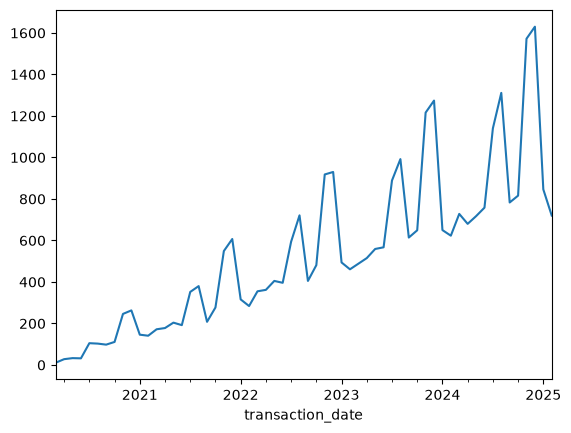

In [8]:
#Is there an overall trend in the number of transactions over time?
print("The number of transactions shows a general increasing trend over time, with some fluctuations.")
print(monthly_transactions.plot(kind="line"))

The number of daily purchases fluctuates from day to day, with larger changes observed in the later years.
Axes(0.125,0.2;0.775x0.68)


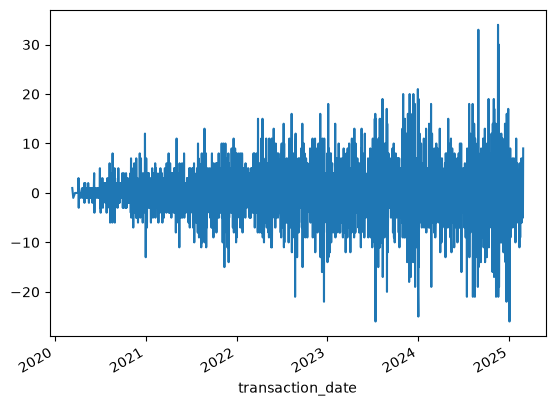

In [35]:
#How does the number of purchases change on a daily basis?
daily_change = transactions.groupby("transaction_date").size()
print("The number of daily purchases fluctuates from day to day, with larger changes observed in the later years.")
print(daily_change.diff().plot(kind="line"))

The number of monthly purchases fluctuates over time, with larger increases and decreases observed in the later years.
Axes(0.125,0.11;0.775x0.77)


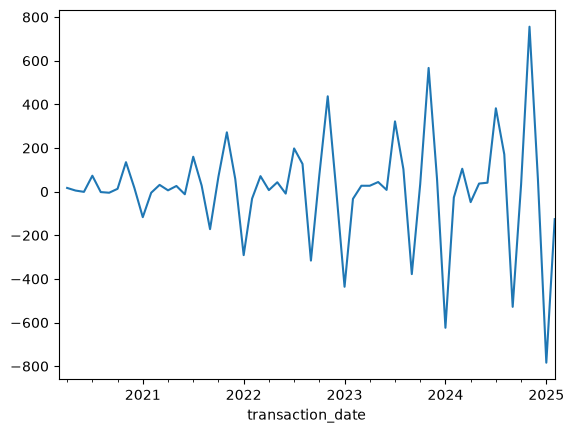

In [37]:
#How does the number of purchases change each month?
monthly_change = transactions.groupby(transactions["transaction_date"].dt.to_period("M")).size()
print("The number of monthly purchases fluctuates over time, with larger increases and decreases observed in the later years.")
print(monthly_change.diff().plot(kind="line"))


transaction_date
2020-03-04          NaN
2020-03-12          NaN
2020-03-16          NaN
2020-03-23          NaN
2020-03-24          NaN
                ...    
2025-02-21    28.428571
2025-02-22    30.285714
2025-02-23    31.000000
2025-02-24    31.142857
2025-02-25    31.571429
Length: 1761, dtype: float64


<Axes: xlabel='transaction_date'>

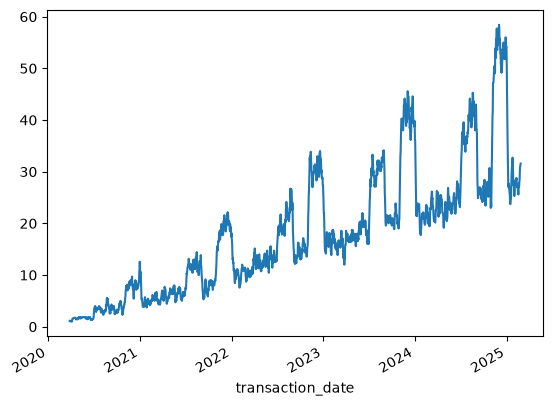

In [34]:
#What is the average number of purchases over a 7-day rolling window?
daily_transactions = transactions.groupby(transactions["transaction_date"]).size()
rolling_7_days = daily_transactions.rolling(7).mean()
print(rolling_7_days)
rolling_7_days.plot(kind="line")

<Axes: xlabel='transaction_date'>

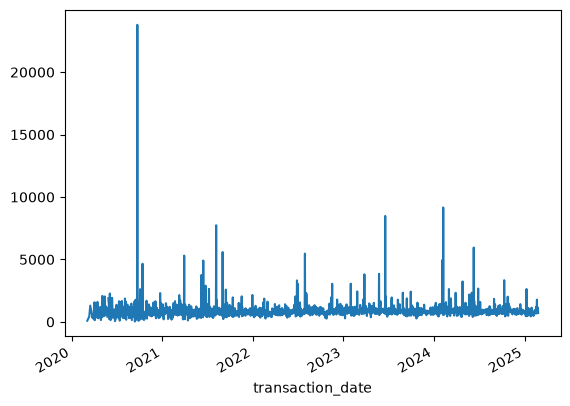

In [45]:
#How does the average purchase value change daily over time?
daily_avg=transactions.groupby("transaction_date")["sales"].mean()
daily_avg.plot(kind="line")


<Axes: xlabel='transaction_date'>

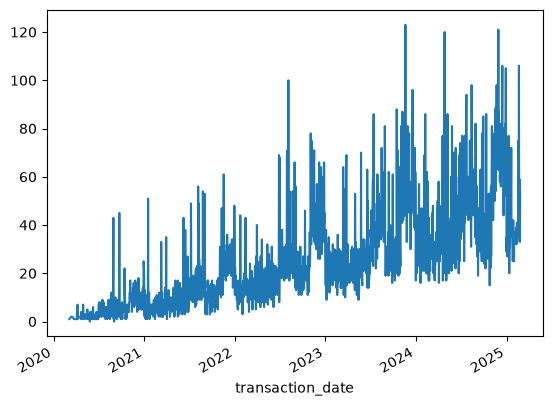

In [49]:
#How does the quantity sold change daily over time?
daily_quantity=transactions.groupby("transaction_date")["quantity"].sum()
daily_quantity.plot(kind="line")

<Axes: xlabel='registration_date'>

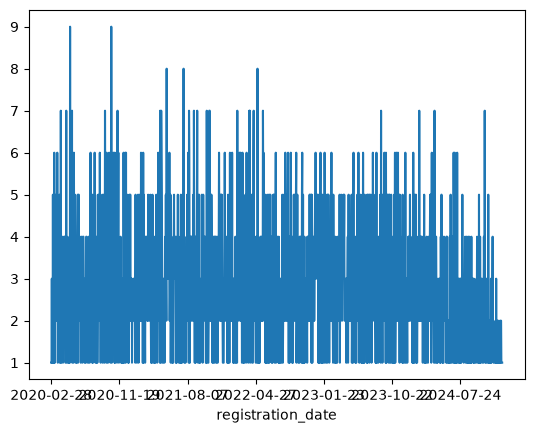

In [ ]:
#How are new customer registrations distributed over time?
new_customers=merged.groupby("registration_date")["customer_id"].nunique()
new_customers.plot(kind="line")

May
427


<Axes: title={'center': 'Number of New Customers by Month'}, xlabel='Month', ylabel='Number of New Customers'>

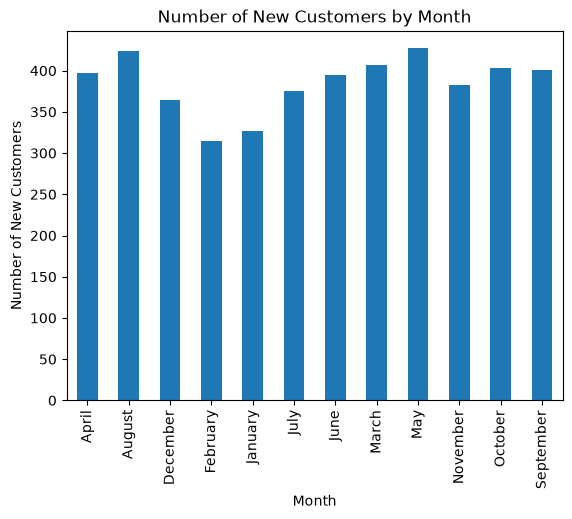

In [68]:
#Which months had the highest number of new customers?
result=merged.groupby(merged["registration_date"].dt.month_name())["customer_id"].nunique()
print(result.idxmax())
print(result.max())
result.plot(kind="bar" , 
    title="Number of New Customers by Month",
    xlabel="Month",
    ylabel="Number of New Customers")


In [71]:
#Were there periods when new customer registrations increased?
registration_change=merged.groupby("registration_date")["customer_id"].nunique()
print(registration_change.diff())

registration_date
2020-02-28    NaN
2020-02-29    0.0
2020-03-01    2.0
2020-03-02   -2.0
2020-03-04    0.0
             ... 
2025-02-14    0.0
2025-02-16   -1.0
2025-02-18    0.0
2025-02-19    0.0
2025-02-22    0.0
Name: customer_id, Length: 1654, dtype: float64


In [78]:
#What is the time between customer registration and their first purchase?
first_purchase = merged.groupby("customer_id")["transaction_date"].min()
duration = first_purchase - merged.groupby("customer_id")["registration_date"].first()
print(duration)
print(duration.mean())

customer_id
00012aa8-e99c-4e30-b3f6-1f7e36adc517   258 days
000feeed-f931-4908-b539-29ab57e595be   139 days
00107f62-0530-48ec-a56a-49d90944eafe   177 days
005ae094-2f68-4a6d-91f0-73b38b890692   206 days
00a6835b-c50a-49a9-a1b5-19d74d3e1863   373 days
                                         ...   
ffb857e7-8c34-4fe1-8b49-37d1507341ea   113 days
ffc456c6-40f3-447e-b67c-57749c6883b3    36 days
ffdde076-9e1e-4368-81b4-7d84cf7e8dc9   133 days
ffe12a11-2bfa-4181-939c-4a8b6125b170   424 days
ffe869c7-5f1e-4c20-aabb-ebee990c4766    12 days
Length: 4618, dtype: timedelta64[us]
137 days 22:04:18.813339


In [ ]:
#Did customers who registered during certain periods become more active than others?
merged["registration_month"] = merged["registration_date"].dt.to_period("M")

activity = merged.groupby(
    ["registration_month", "customer_id"]
).size()

activity.groupby("registration_month").mean()

registration_month
2020-02    11.500000
2020-03    12.725000
2020-04    11.391892
2020-05    11.686047
2020-06    12.109756
             ...    
2024-10     1.833333
2024-11     1.462963
2024-12     1.222222
2025-01     1.421053
2025-02     1.166667
Freq: M, Length: 61, dtype: float64

In [5]:
transactions = transactions.set_index("transaction_date")

In [ ]:
#resample() groups data by time periods and can include periods with no data, while groupby() only groups values that exist in the data.
transactions.resample("D")["transaction_id"].size()

transaction_date
2020-03-04     1
2020-03-05     0
2020-03-06     0
2020-03-07     0
2020-03-08     0
              ..
2025-02-21    31
2025-02-22    35
2025-02-23    33
2025-02-24    28
2025-02-25    37
Freq: D, Name: transaction_id, Length: 1820, dtype: int64

In [11]:
transactions.resample("D")["sales"].sum()

transaction_date
2020-03-04       91.17
2020-03-05        0.00
2020-03-06        0.00
2020-03-07        0.00
2020-03-08        0.00
                ...   
2025-02-21    20927.39
2025-02-22    26682.20
2025-02-23    23003.11
2025-02-24    30624.94
2025-02-25    24763.65
Freq: D, Name: sales, Length: 1820, dtype: float64

In [14]:
transactions.resample("ME")["quantity"].sum()

transaction_date
2020-03-31      12.0
2020-04-30      43.0
2020-05-31      44.0
2020-06-30      38.0
2020-07-31     130.0
2020-08-31     173.0
2020-09-30     171.0
2020-10-31     161.0
2020-11-30     326.0
2020-12-31     332.0
2021-01-31     221.0
2021-02-28     162.0
2021-03-31     274.0
2021-04-30     217.0
2021-05-31     260.0
2021-06-30     321.0
2021-07-31     474.0
2021-08-31     593.0
2021-09-30     316.0
2021-10-31     349.0
2021-11-30     757.0
2021-12-31     813.0
2022-01-31     423.0
2022-02-28     402.0
2022-03-31     474.0
2022-04-30     460.0
2022-05-31     526.0
2022-06-30     530.0
2022-07-31     897.0
2022-08-31    1134.0
2022-09-30     576.0
2022-10-31     642.0
2022-11-30    1344.0
2022-12-31    1311.0
2023-01-31     678.0
2023-02-28     618.0
2023-03-31     796.0
2023-04-30     649.0
2023-05-31     777.0
2023-06-30     807.0
2023-07-31    1285.0
2023-08-31    1342.0
2023-09-30     884.0
2023-10-31     954.0
2023-11-30    1733.0
2023-12-31    1707.0
2024-01-31     89

<Axes: xlabel='transaction_date'>

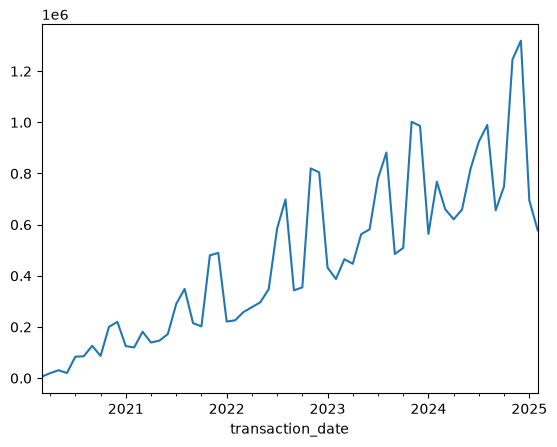

In [26]:
monthly_sales=transactions.resample("ME")["sales"].sum()
monthly_sales.plot(kind="line")

In [15]:
transactions.resample("ME")["sales"].mean()

transaction_date
2020-03-31     513.665455
2020-04-30     693.704286
2020-05-31     964.765000
2020-06-30     667.288333
2020-07-31     839.648600
2020-08-31     847.115248
2020-09-30    1331.485684
2020-10-31     811.347815
2020-11-30     838.448536
2020-12-31     869.588249
2021-01-31     926.551101
2021-02-28     890.545704
2021-03-31    1106.157988
2021-04-30     814.015088
2021-05-31     736.722847
2021-06-30     936.533323
2021-07-31     854.124949
2021-08-31     963.715936
2021-09-30    1075.540400
2021-10-31     771.599885
2021-11-30     910.573930
2021-12-31     835.573400
2022-01-31     737.193313
2022-02-28     824.790438
2022-03-31     755.775685
2022-04-30     787.714315
2022-05-31     762.210714
2022-06-30     922.627150
2022-07-31    1025.572746
2022-08-31    1001.007552
2022-09-30     882.065123
2022-10-31     753.585166
2022-11-30     928.320799
2022-12-31     905.179499
2023-01-31     905.392079
2023-02-28     866.973861
2023-03-31     984.615444
2023-04-30     901.56

2024-12-01 00:00:00 58.42857142857143


<Axes: xlabel='transaction_date'>

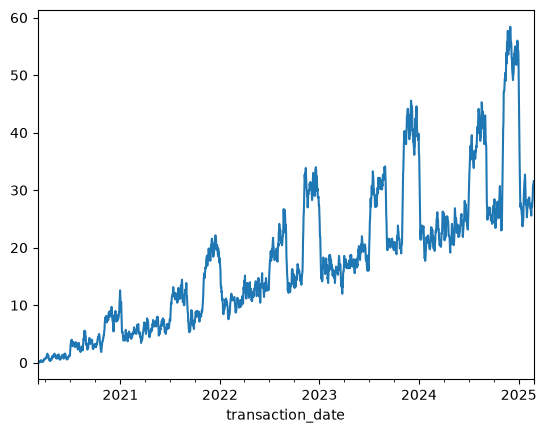

In [24]:
daily_transactions = transactions.resample("D").size()
res = daily_transactions.rolling(7).mean()
print(res.idxmax(),res.max())
res.plot(kind="line")


In [ ]:
daily_sales=transactions.resample("D")["sales"].mean()
daily_sales.rolling(7).mean()